In [1]:
%load_ext autoreload
%autoreload 2

import pickle
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent))
import MixedEffectsModeling.config as config
from viz_style import apply_style
apply_style()

import json

OC = config.OUTRIDER_COMPARISON_DIR
pd.set_option("display.width", 120)


In [2]:
cov = pd.read_csv(OC / "gene_coverage_by_expression.csv", index_col=0)
cov["nz_bin"] = pd.Categorical(cov["nz_bin"],
    categories=["1-10", "11-30(pool)", "31-100", "101-300", "301-676(near-universal)"], ordered=True)

tab1 = cov.groupby("nz_bin", observed=True).agg(
    n_genes=("nz", "size"),
    our_engine_modeled_frac=("engine_ok", "mean"),
    outrider_fpkm_pass_frac=("outrider_pass", "mean"),
).round(3)
print("Coverage by detection-frequency stratum (fraction of genes each engine can model):")
tab1

Coverage by detection-frequency stratum (fraction of genes each engine can model):


,n_genes,our_engine_modeled_frac,outrider_fpkm_pass_frac
nz_bin,,,
1-10,873,1.0,0.000
11-30(pool),1227,1.0,0.000
31-100,2206,1.0,0.013
101-300,2972,1.0,0.201
301-676(near-universal),12580,1.0,0.947


In [3]:
training_summary = pd.read_csv(config.ENGINE_MIXED_DIR / "training_summary.csv")
n_universe_ours = len(training_summary)
n_ok_ours = int(training_summary["ok"].sum())
n_excluded_ours = n_universe_ours - n_ok_ours

fold_stats = pd.read_csv(config.CV_MIXED_DIR / "fold_stats.csv")
per_gene_fold = fold_stats.groupby("gene")["ok"].agg(["sum", "count"])
n_stable_all_folds = int((per_gene_fold["sum"] == per_gene_fold["count"]).sum())
n_any_fold_fail = int((per_gene_fold["sum"] < per_gene_fold["count"]).sum())
n_model_route = len(per_gene_fold)

outrider_summary = json.load(open(OC / "outrider_coverage_summary.json"))
n_universe_outr = outrider_summary["universe_genes"]
n_fpkm_pass = outrider_summary["fpkm_filter_pass"]
n_fit_dropped = outrider_summary["n_nb_fit_dropped"]
n_final_outr = outrider_summary["final_modeled_genes_actual"]

coverage_table = pd.DataFrame([
    ["universe attempted", f"{n_universe_ours:,} (all protein-coding)", f"{n_universe_outr:,} (our engine's own successful set)"],
    ["upstream filter pass", "--", f"{n_fpkm_pass:,} ({n_fpkm_pass/n_universe_outr:.1%}, FPKM>=1)"],
    ["fit failures", f"{n_excluded_ours:,} ({n_excluded_ours/n_universe_ours:.1%}, cascade excluded)", f"{n_fit_dropped:,} (NB optimizer, identical every CV fold)"],
    ["CV-fold stable (model route)", f"{n_stable_all_folds:,}/{n_model_route:,} ({n_stable_all_folds/n_model_route:.1%})", "--"],
    ["CV-fold failing >=1 (model route)", f"{n_any_fold_fail:,}/{n_model_route:,} ({n_any_fold_fail/n_model_route:.1%})", "--"],
    ["final modeled genes", f"{n_ok_ours:,} ({n_ok_ours/n_universe_ours:.1%})", f"{n_final_outr:,} ({n_final_outr/n_universe_outr:.1%})"],
], columns=["metric", "our engine", "OUTRIDER"]).set_index("metric")
coverage_table.to_clipboard(excel=True)


In [4]:
eng_cv = pd.read_csv(config.CV_MIXED_DIR / "cv_stats.csv").set_index("gene")
outr_cv = pd.read_csv(OC / "outrider_cv_metrics.csv").set_index("gene")
common_genes = eng_cv.index.intersection(outr_cv.index)
print(f"OUTRIDER-fittable genes: {len(outr_cv)}, of which also in our engine CV set: {len(common_genes)}")

with open(config.CV_MIXED_DIR / "cv_zscores_shash.pkl", "rb") as f:
    shash_z = pickle.load(f)
shash_mean = pd.Series({g: np.nanmean(v) for g, v in shash_z.items()})
shash_std = pd.Series({g: np.nanstd(v) for g, v in shash_z.items()})

eng_full = eng_cv[["mean_z", "std_z", "cv_raw_skew", "cv_raw_kurtosis", "cv_corrected_skew",
                    "cv_corrected_kurtosis", "cv_naive_exceed", "cv_shash_exceed"]].median()
eng_sub = eng_cv.loc[common_genes, ["mean_z", "std_z", "cv_raw_skew", "cv_raw_kurtosis", "cv_naive_exceed"]].median()
outr_med = outr_cv[["mean_z", "std_z", "skew_z", "kurt_z", "naive_exceed"]].median()

zmoments = pd.DataFrame({
    "our_engine_raw (full 19858g)": eng_full.reindex(["mean_z","std_z","cv_raw_skew","cv_raw_kurtosis","cv_naive_exceed"]).values,
    "our_engine_shash (full 19858g)": [shash_mean.median(), shash_std.median(), eng_full["cv_corrected_skew"], eng_full["cv_corrected_kurtosis"], eng_full["cv_shash_exceed"]],
    "our_engine_raw (12305g subset)": eng_sub.values,
    "outrider_raw (12305g)": outr_med.values,
}, index=["mean(Z)", "std(Z)", "skew(Z)", "kurtosis(Z)", "naive_exceed |Z|>1.96"])
zmoments.to_clipboard(excel=True)


OUTRIDER-fittable genes: 12305, of which also in our engine CV set: 12305


In [5]:
eng_ppc = pd.read_csv(config.CV_MIXED_DIR / "cv_calibration_moments.csv").set_index("gene")
outr_ppc = pd.read_csv(OC / "outrider_cv_calibration_moments.csv").set_index("gene")

common_ppc_genes = eng_ppc.index.intersection(outr_ppc.index)
print(f"our engine PPC genes: {len(eng_ppc)} | OUTRIDER PPC genes: {len(outr_ppc)} | common: {len(common_ppc_genes)}")

eng_ppc_full = eng_ppc.median()
eng_ppc_sub = eng_ppc.loc[common_ppc_genes].median()
outr_ppc_med = outr_ppc.median()
ppc_table = pd.DataFrame({
    "our_engine (full 19858g)": eng_ppc_full.reindex(["obs_mean","pred_mean","obs_var","pred_var","obs_zero","pred_zero"]).values,
    "our_engine (12305g subset)": eng_ppc_sub.reindex(["obs_mean","pred_mean","obs_var","pred_var","obs_zero","pred_zero"]).values,
    "outrider (12305g)": outr_ppc_med.reindex(["obs_mean","pred_mean","obs_var","pred_var","obs_zero","pred_zero"]).values,
}, index=["mean (obs)", "mean (pred)", "std (obs)", "std (pred)", "zero-frac (obs)", "zero-frac (pred)"])
ppc_table


our engine PPC genes: 19858 | OUTRIDER PPC genes: 12305 | common: 12305


,our_engine (full 19858g),our_engine (12305g subset),outrider (12305g)
mean (obs),28.432692,106.890533,106.890533
mean (pred),29.164234,108.640407,113.467825
std (obs),67.865777,172.779542,172.779542
std (pred),95.376236,213.411176,214.177338
zero-frac (obs),0.239645,0.059172,0.059172
zero-frac (pred),0.208794,0.037367,0.022463


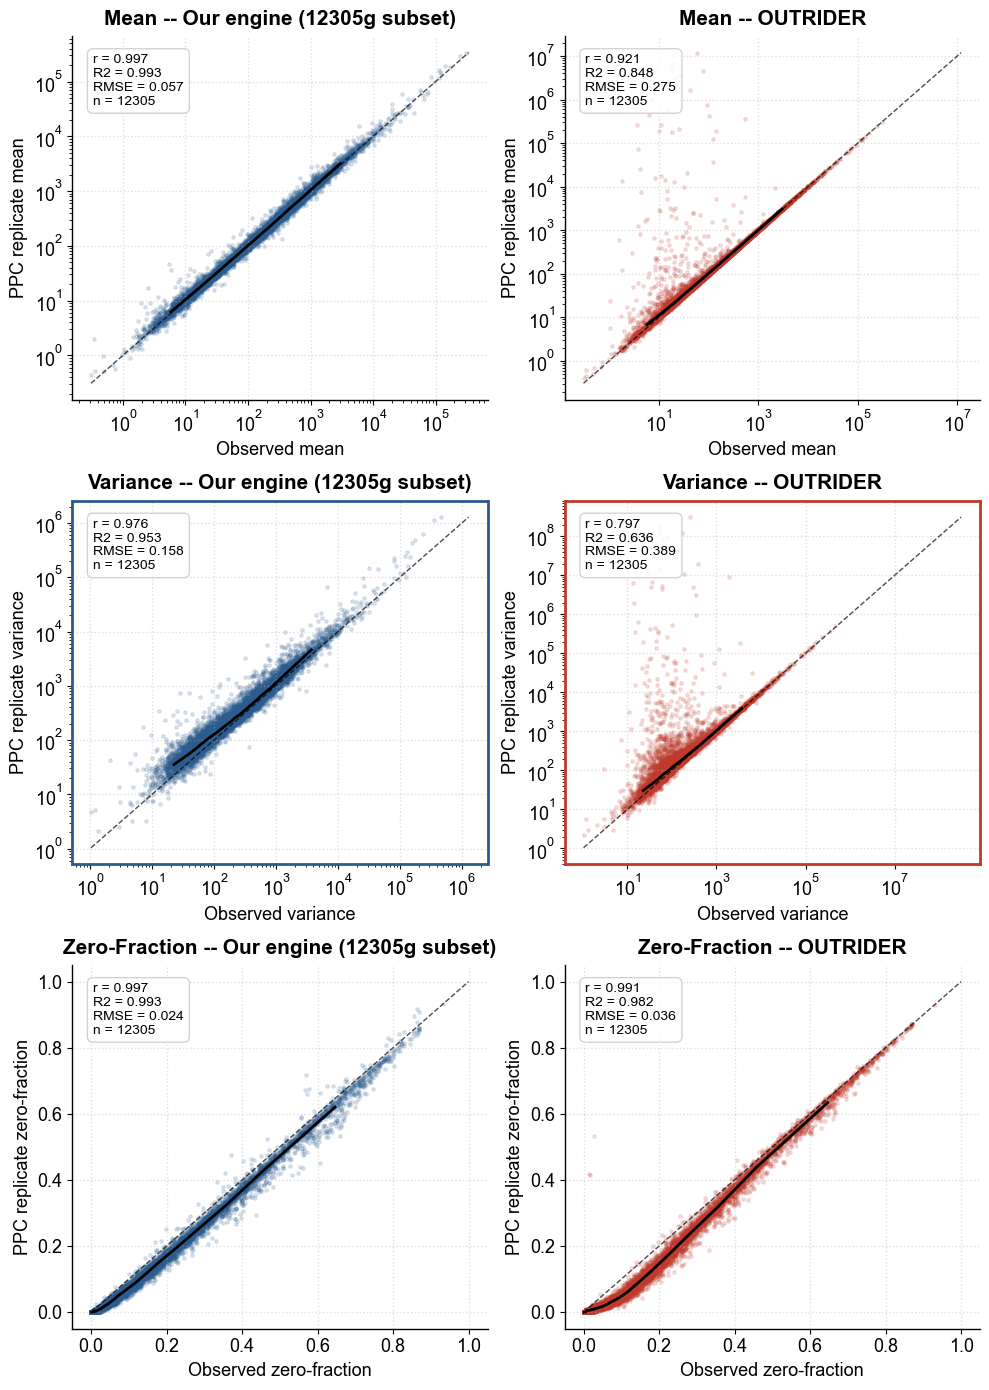

In [6]:
from MixedEffectsModeling.validation.ppc_simulate import binned_medians, calib_stats

eng_sub_cal = pd.read_csv(OC / "our_engine_cv_calibration_moments_12305subset.csv")
outr_cal = pd.read_csv(OC / "outrider_cv_calibration_moments.csv")

panels = [("obs_mean", "pred_mean", "Mean", True), ("obs_var", "pred_var", "Variance", True),
         ("obs_zero", "pred_zero", "Zero-Fraction", False)]
engines = [("Our engine (12305g subset)", eng_sub_cal, "#2b5c8f"), ("OUTRIDER", outr_cal, "#c0392b")]

fig, axes = plt.subplots(3, 2, figsize=(10, 14))

for row, (oc, pc, title_str, logsc) in enumerate(panels):
    xlim = None
    for col, (eng_label, cal, color) in enumerate(engines):
        ax = axes[row, col]
        ax.scatter(cal[oc], cal[pc], s=6, alpha=0.15, color=color)
        bx, by = binned_medians(cal[oc], cal[pc])
        ax.plot(bx, by, '-', color='black', linewidth=2)

        if logsc:
            lo = max(min(cal[oc].min(), cal[pc].min()), 1e-3)
            hi = max(cal[oc].max(), cal[pc].max())
            ax.plot([lo, hi], [lo, hi], 'k--', linewidth=1, alpha=0.7)
            ax.set_xscale('log'); ax.set_yscale('log')
        else:
            ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.7)

        cs = calib_stats(cal[oc], cal[pc], logsc)
        ax.set_title(f"{title_str} -- {eng_label}", fontweight='bold', pad=8)
        ax.set_xlabel(f'Observed {title_str.lower()}')
        ax.set_ylabel(f'PPC replicate {title_str.lower()}')
        stats_text = "r = {pearson_r:.3f}\nR2 = {r2:.3f}\nRMSE = {rmse:.3f}\nn = {n}".format(**cs)
        ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85, edgecolor='#cccccc'))
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
        ax.grid(True, linestyle=':', alpha=0.4)
        if row == 1:
            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_edgecolor('#c0392b' if col == 1 else '#2b5c8f')
                spine.set_linewidth(2)

plt.tight_layout()
fig.savefig(OC / 'Figures' / 'ppc_scatter_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

In [7]:
calib = pd.read_csv(OC / "ppc_calib_stats.csv")
calib_wide = calib.pivot(index="panel", columns="engine",
                         values=["pearson_r", "r2", "spearman_rho", "rmse", "mae"])
calib_wide = calib_wide.reindex(["mean", "var", "zero_frac"])
calib_wide = calib_wide.reindex(columns=["our_engine_full19858", "our_engine_12305subset", "outrider_12305"], level=1)
calib_wide

pearson_r                                                         r2                         \
engine    our_engine_full19858 our_engine_12305subset outrider_12305 our_engine_full19858 our_engine_12305subset   
panel                                                                                                              
mean                  0.994724               0.996668       0.920928             0.989476               0.993347   
var                   0.968040               0.976067       0.797423             0.937101               0.952707   
zero_frac             0.999204               0.996640       0.990963             0.998408               0.993290   

                                 spearman_rho                                                       rmse  \
engine    outrider_12305 our_engine_full19858 our_engine_12305subset outrider_12305 our_engine_full19858   
panel                                                                                                      
mean            0.848109             0.994357               0.997296       0.968982             0.106802   
var             0.635883             0.972872               0.975402       0.912078             0.257652   
zero_frac       0.982008             0.998285               0.994491       0.987853             0.020782   

                                                                 mae                                        
engine    our_engine_12305subset outrider_12305 our_engine_full19858 our_engine_12305subset outrider_12305  
panel                                                                                                       
mean                    0.056810       0.274961             0.047371               0.036443       0.045216  
var                     0.157936       0.389463             0.154947               0.115384       0.118162  
zero_frac               0.024257       0.035696             0.015655               0.019473       0.027574

In [8]:
import pickle as _pkl

from MixedEffectsModeling.validation.lobo_mmd import plot_mmd_direction, short_batch_label
from MixedEffectsModeling.validation import lobo_mmd

HO = config.OUTRIDER_COMPARISON_DIR.parent / 'held_out_comparison'

arms = {'our_engine': lobo_mmd.load_engine_arm(shash=True, ood_filter=True)}
arms['outrider_insample'] = lobo_mmd.load_csv_arm(OC, arms['our_engine'])
arms['outrider_heldout'] = lobo_mmd.load_csv_arm(HO, arms['our_engine'])

# gene-matched engine arm: OUTRIDER drops ~38% of genes at its own FPKM filter, so the
# unmatched comparison confounds method with gene universe
_src = next((d for d in (OC, HO) if arms[f"outrider_{'insample' if d is OC else 'heldout'}"]), None)
if _src is not None:
    gene_names = _pkl.load(open(next(config.LOBO_MIXED_DIR.glob('*/gene_names.pkl')), 'rb'))
    outr_genes = pd.read_csv(next(_src.glob('z_test_*.csv')), index_col=0, nrows=1).columns
    col = np.flatnonzero(np.isin(gene_names, outr_genes))
    arms['our_engine_genematched'] = {b: dict(a, Z=a['Z'][:, col])
                                      for b, a in arms['our_engine'].items()}

dist, raw, nsig = {}, {}, {}
for tag, arm in arms.items():
    if not arm:
        print(f'{tag}: no Z found, skipped (run the OUTRIDER LOBO stages first)')
        continue
    dist[tag], raw[tag] = lobo_mmd.rkhs_stats(arm)
    nsig[tag] = lobo_mmd.nsig_stats(lobo_mmd.nsig_table(arm))

rows = []
for tag in dist:
    d = dist[tag].set_index('batch')
    n = nsig[tag].set_index('batch')
    for b in d.index:
        rows.append(dict(arm=tag, batch=short_batch_label(b), n_gene=d.loc[b, 'n_gene'],
                         dist_auc=d.loc[b, 'auc'], dist_q=d.loc[b, 'bh_q'],
                         nsig_auc=n.loc[b, 'auc'], nsig_q=n.loc[b, 'bh_q']))
cmp = pd.DataFrame(rows)
for tag in dist:
    print(f"{tag:26s} distance q<0.05: {(dist[tag].bh_q < 0.05).sum()}/{len(dist[tag])}   "
          f"n_sig q<0.05: {(nsig[tag].bh_q < 0.05).sum()}/{len(nsig[tag])}")
cmp.pivot(index='batch', columns='arm', values=['dist_auc', 'nsig_auc']).round(3)


direction-significant (p_direction<0.05): ours=6/6  outrider=1/6
direction sign correct (disease_farther=True): ours=6/6  outrider=4/6


,batch,n_hc,n_dis,perm_p_ours,p_direction_ours,disease_farther_ours,perm_p_outrider,p_direction_outrider,disease_farther_outrider
0,Ward Z et al._Batch_1,116,224,0.000999,4.153482e-15,True,0.000999,6.384674e-15,True
1,Moore et al._Batch_1,71,173,0.214785,8.743483e-03,True,0.407592,7.564472e-01,False
2,Roskams-Hieter B et al._Batch_2,27,58,0.036963,8.797911e-03,True,0.006993,1.887299e-01,True
3,Moufarrej et al._Batch_4,47,39,0.058941,2.752677e-03,True,0.072927,5.993108e-01,True
4,Chen et al._Batch_2,31,32,0.011988,3.221963e-02,True,0.042957,2.106212e-01,True
5,Moufarrej et al._Batch_1,54,23,0.002997,2.410473e-02,True,0.006993,7.425045e-01,False


In [ ]:
FIG = OC / 'Figures'
FIG.mkdir(parents=True, exist_ok=True)


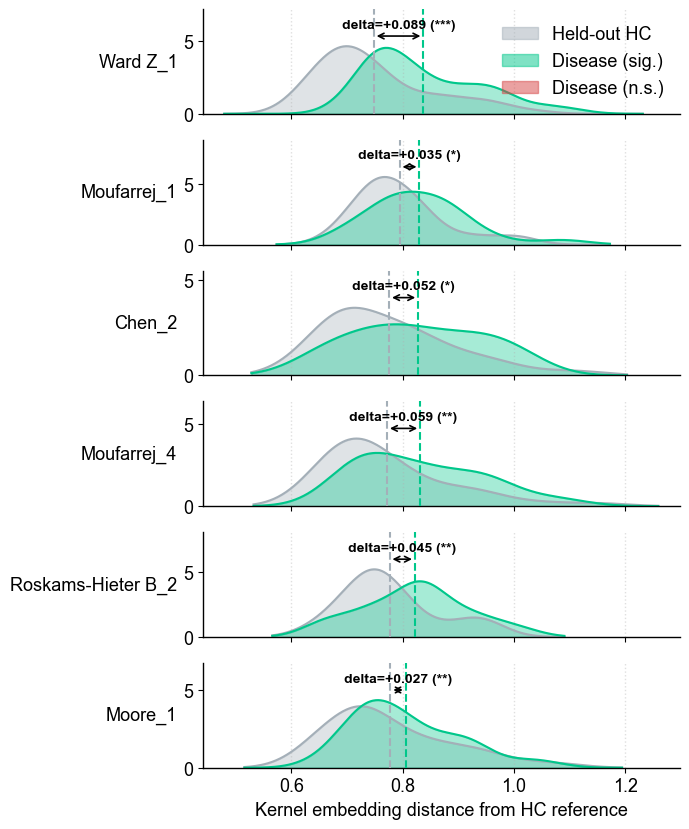

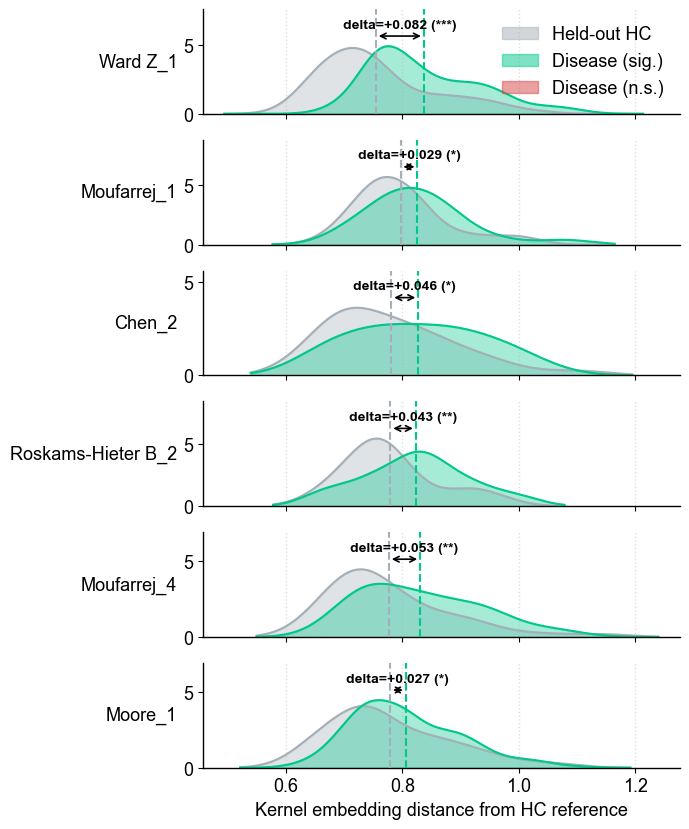

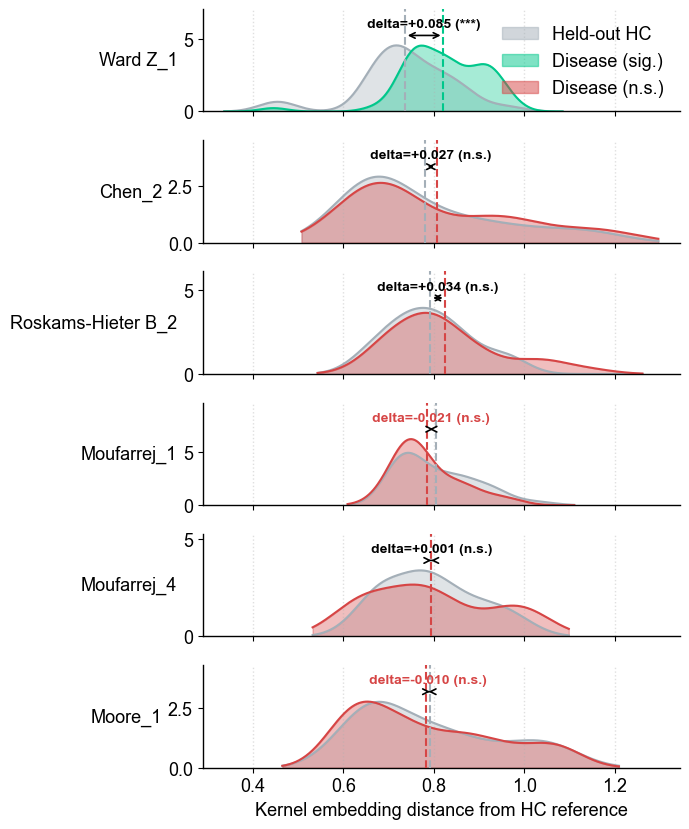

In [13]:
for tag in dist:
    plot_mmd_direction(dist[tag], raw[tag], FIG / f'mmd_direction_{tag}.png',
                       p_col='mw_p', sort_col='auc', row_h=1.2)
    lobo_mmd.plot_nsig_box(lobo_mmd.nsig_table(arms[tag]), nsig[tag], tag,
                           FIG / f'nsig_{tag}.png')
    plt.close('all')
